# Cluster Evaluation

## Overview

Clustering is unsupervised — there are no ground truth labels to score against. Evaluation uses either internal metrics (based on the data alone) or external metrics (when reference labels exist for benchmarking).

**Internal metrics (no ground truth needed):**

| Metric | Best value | Measures |
|---|---|---|
| Silhouette score | +1 | Cohesion and separation |
| Davies-Bouldin index | 0 (lower=better) | Average cluster similarity |
| Calinski-Harabasz | Higher=better | Ratio of between/within scatter |

**External metrics (when reference labels exist):**

| Metric | Best value | Measures |
|---|---|---|
| Adjusted Rand Index (ARI) | 1.0 | Agreement corrected for chance |
| Normalised Mutual Information | 1.0 | Information overlap |
| Homogeneity / Completeness | 1.0 | Label purity measures |

---

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
    calinski_harabasz_score, adjusted_rand_score,
    normalized_mutual_info_score, homogeneity_completeness_v_measure)
from sklearn.decomposition import PCA

rng = np.random.default_rng(42)
centers = [(0,0),(5,1),(2.5,5),(8,5)]
X_list, true_labels = [], []
for i, (cx, cy) in enumerate(centers):
    n = rng.integers(60,80)
    X_list.append(rng.normal([cx,cy], 0.8, (n,2)))
    true_labels.extend([i]*n)
X = np.vstack(X_list)
true_labels = np.array(true_labels)
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)
print(f"Dataset: {X.shape}, true clusters: {len(set(true_labels))}")

Dataset: (264, 2), true clusters: 4


---
## Internal Metrics Across k

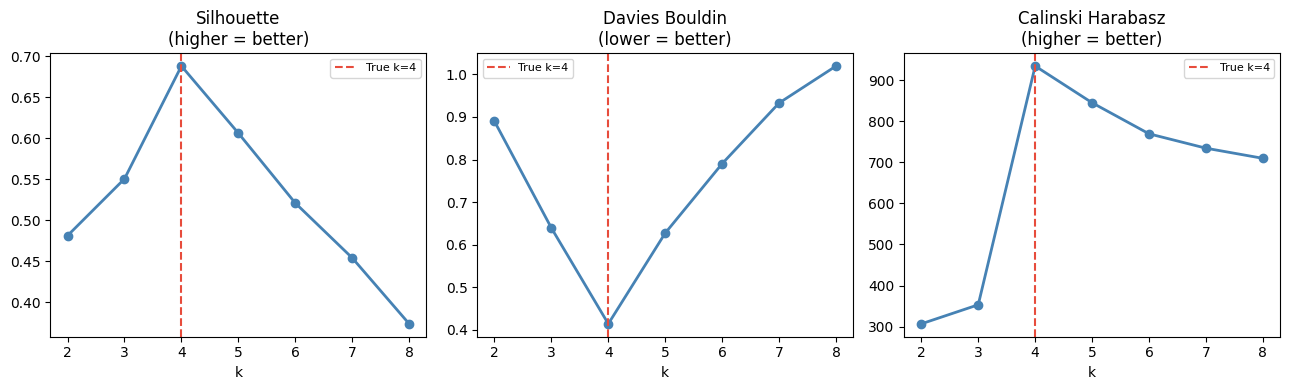

In [7]:
ks = range(2, 9)
metrics = {"silhouette":[], "davies_bouldin":[], "calinski_harabasz":[]}
for k in ks:
    lbl = KMeans(n_clusters=k, n_init=20, random_state=42).fit_predict(X_sc)
    metrics["silhouette"].append(silhouette_score(X_sc, lbl))
    metrics["davies_bouldin"].append(davies_bouldin_score(X_sc, lbl))
    metrics["calinski_harabasz"].append(calinski_harabasz_score(X_sc, lbl))

fig, axes = plt.subplots(1,3,figsize=(13,4))
for ax, (name, vals), better in zip(axes, metrics.items(),
                                     ["higher","lower","higher"]):
    ax.plot(ks, vals, "o-", color="steelblue", lw=2)
    ax.axvline(4, color="#e74c3c", lw=1.5, linestyle="--", label="True k=4")
    ax.set_xlabel("k"); ax.set_title(f"{name.replace("_"," ").title()}\n({better} = better)")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

---
## Comparing Algorithms with Internal Metrics

In [8]:
algorithms = {
    "KMeans":        KMeans(n_clusters=4, n_init=20, random_state=42),
    "Agglomerative": AgglomerativeClustering(n_clusters=4, linkage="ward"),
    "GMM":           GaussianMixture(n_components=4, n_init=10, random_state=42),
}
rows = []
for name, algo in algorithms.items():
    if hasattr(algo, "fit_predict"):
        lbl = algo.fit_predict(X_sc)
    else:
        lbl = algo.fit(X_sc).predict(X_sc)
    rows.append({
        "Algorithm":          name,
        "Silhouette":         silhouette_score(X_sc, lbl),
        "Davies-Bouldin":     davies_bouldin_score(X_sc, lbl),
        "Calinski-Harabasz":  calinski_harabasz_score(X_sc, lbl),
        "ARI (vs true)":      adjusted_rand_score(true_labels, lbl),
    })
print(pd.DataFrame(rows).set_index("Algorithm").round(3))

               Silhouette  Davies-Bouldin  Calinski-Harabasz  ARI (vs true)
Algorithm                                                                  
KMeans              0.688           0.414            934.732          0.989
Agglomerative       0.684           0.423            912.753          0.968
GMM                 0.688           0.414            934.732          0.989


---
## External Metrics (ARI, NMI, Homogeneity)

In [9]:
km_labels = KMeans(n_clusters=4, n_init=20, random_state=42).fit_predict(X_sc)
ari = adjusted_rand_score(true_labels, km_labels)
nmi = normalized_mutual_info_score(true_labels, km_labels)
hom, com, v = homogeneity_completeness_v_measure(true_labels, km_labels)
print(f"Adjusted Rand Index:   {ari:.3f}  (1.0=perfect, 0.0=random)")
print(f"Normalised Mutual Info: {nmi:.3f}  (1.0=perfect)")
print(f"Homogeneity:           {hom:.3f}  (each cluster contains only one class)")
print(f"Completeness:          {com:.3f}  (all members of a class in same cluster)")
print(f"V-measure (harmonic):  {v:.3f}")

Adjusted Rand Index:   0.989  (1.0=perfect, 0.0=random)
Normalised Mutual Info: 0.986  (1.0=perfect)
Homogeneity:           0.986  (each cluster contains only one class)
Completeness:          0.985  (all members of a class in same cluster)
V-measure (harmonic):  0.986


---
## Stability Assessment

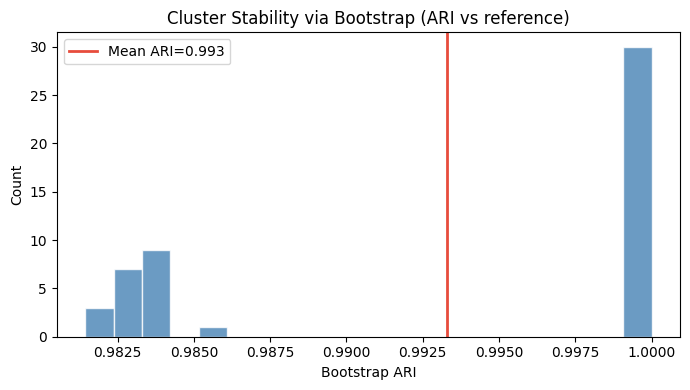

In [10]:
# Bootstrap cluster stability: resample data, refit, measure ARI vs original
ref_labels = KMeans(n_clusters=4, n_init=20, random_state=42).fit_predict(X_sc)
aris = []
for seed in range(50):
    idx = np.random.default_rng(seed).choice(len(X_sc), len(X_sc), replace=True)
    X_boot = X_sc[idx]
    lbl_boot = KMeans(n_clusters=4, n_init=10, random_state=seed).fit_predict(X_boot)
    # Build mapping from original index -> first position in bootstrap sample
    pos_of = -np.ones(len(X_sc), dtype=int)
    for pos, orig in enumerate(idx):
        if pos_of[orig] == -1:
            pos_of[orig] = pos
    unique_idx = np.where(pos_of != -1)[0]
    mapped_positions = pos_of[unique_idx]
    aris.append(adjusted_rand_score(ref_labels[unique_idx], lbl_boot[mapped_positions]))
plt.figure(figsize=(7,4))
plt.hist(aris, bins=20, color="steelblue", edgecolor="white", alpha=0.8)
plt.axvline(np.mean(aris), color="#e74c3c", lw=2, label=f"Mean ARI={np.mean(aris):.3f}")
plt.xlabel("Bootstrap ARI"); plt.ylabel("Count")
plt.title("Cluster Stability via Bootstrap (ARI vs reference)")
plt.legend(); plt.tight_layout(); plt.show()

---

## Common Pitfalls

**1. Selecting k solely to maximise silhouette score**  
Internal metrics can favour compact, well-separated clusters even when the true structure is more complex or overlapping. Always combine metric-based selection with domain knowledge and visual inspection of cluster profiles.

**2. Using ARI or NMI as the primary evaluation metric when reference labels come from a different process**  
External metrics compare cluster assignments to reference labels. If those labels reflect a different grouping concept than the clustering objective, high ARI means the algorithm found the reference grouping, not necessarily the best unsupervised structure.

**3. Comparing silhouette scores across different algorithms without acknowledging their different distance assumptions**  
DBSCAN noise points (-1) distort silhouette computation. GMM soft assignments are binarised for silhouette. Silhouette values are not directly comparable across algorithms with fundamentally different assignment mechanisms.

**4. Not assessing stability**  
A clustering solution that changes substantially across bootstrap resamples is not reliable, regardless of its silhouette score. High internal metrics on a single run can reflect overfitting to noise. Bootstrap stability assessment is a necessary complement.

**5. Reporting only the best metric across many k values without correction**  
Testing k=2 through k=20 and reporting the best silhouette is analogous to p-hacking. The optimal k on a given dataset may reflect noise. Pre-specify a reasonable range based on domain knowledge and report the full metric curve.

---
*python_methods_library - Samantha McGarrigle*